In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
data = fetch_california_housing()
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [ ]:
df=pd.DataFrame(data.data, columns=data.feature_names)
df['PRICE']=data.target

In [ ]:
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PRICE       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [ ]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         PRICE  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [ ]:
print("missing Values:")
print(df.isnull().sum())

missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64


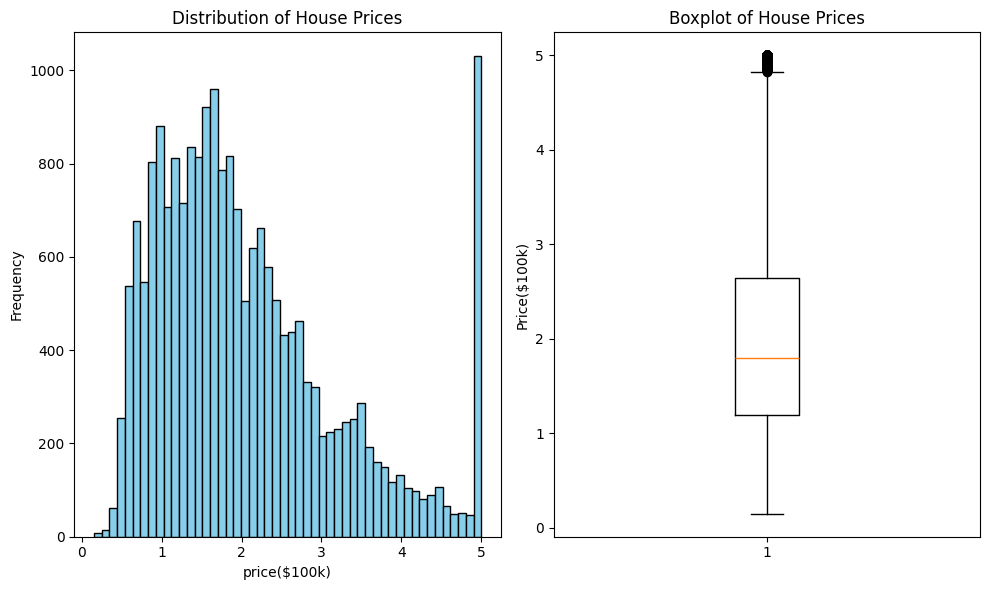

In [ ]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.hist(df['PRICE'], bins=50,color='skyblue',edgecolor='black')
plt.xlabel('price($100k)')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')

plt.subplot(1,2,2)
plt.boxplot(df['PRICE'])
plt.ylabel('Price($100k)')
plt.title('Boxplot of House Prices')

plt.tight_layout()
plt.show()

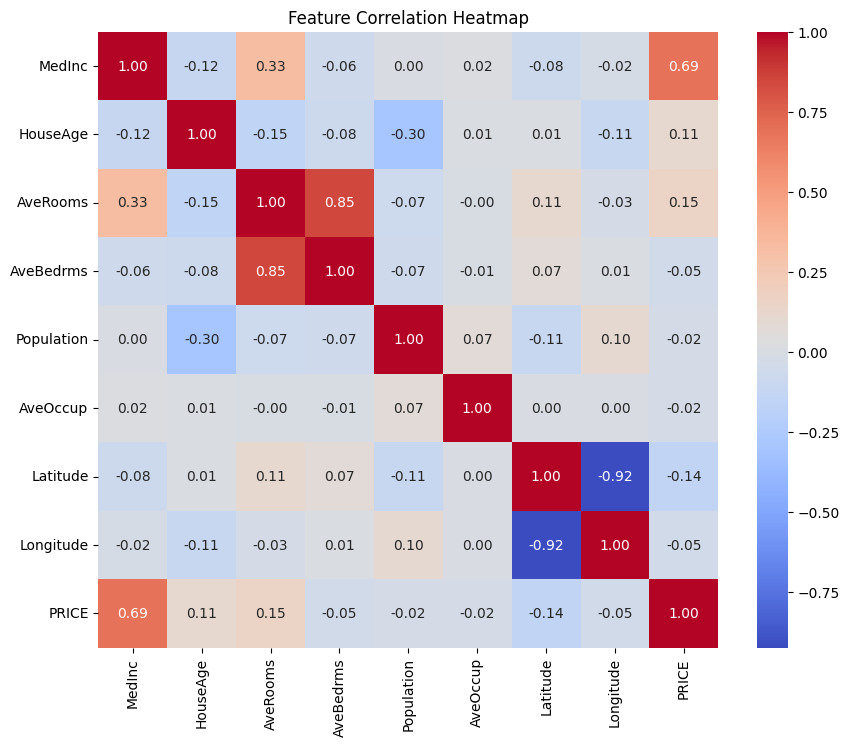

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

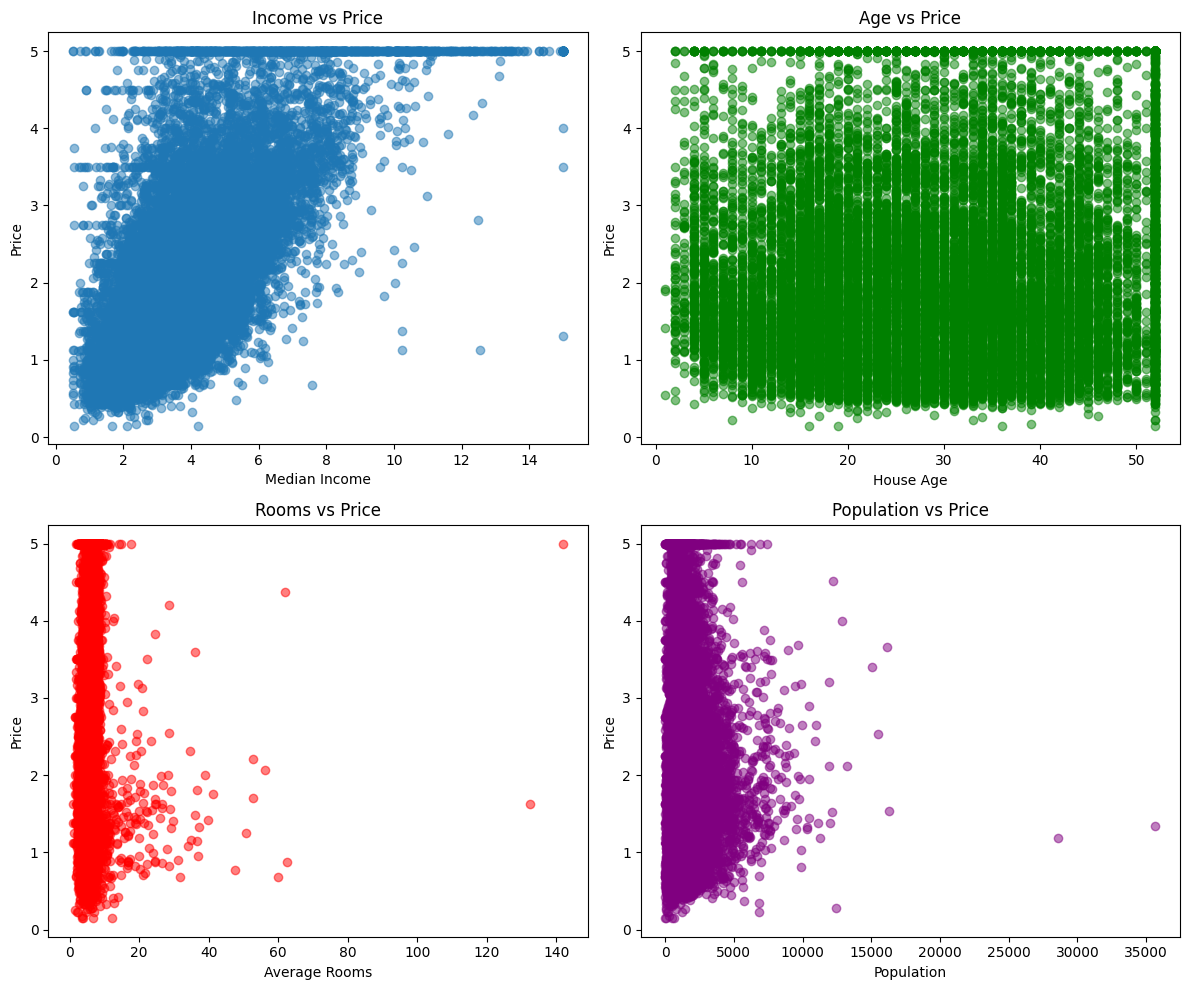

In [ ]:
# Top features ka scatter plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(df['MedInc'], df['PRICE'], alpha=0.5)
axes[0, 0].set_xlabel('Median Income')
axes[0, 0].set_ylabel('Price')
axes[0, 0].set_title('Income vs Price')

axes[0, 1].scatter(df['HouseAge'], df['PRICE'], alpha=0.5, color='green')
axes[0, 1].set_xlabel('House Age')
axes[0, 1].set_ylabel('Price')
axes[0, 1].set_title('Age vs Price')

axes[1, 0].scatter(df['AveRooms'], df['PRICE'], alpha=0.5, color='red')
axes[1, 0].set_xlabel('Average Rooms')
axes[1, 0].set_ylabel('Price')
axes[1, 0].set_title('Rooms vs Price')

axes[1, 1].scatter(df['Population'], df['PRICE'], alpha=0.5, color='purple')
axes[1, 1].set_xlabel('Population')
axes[1, 1].set_ylabel('Price')
axes[1, 1].set_title('Population vs Price')

plt.tight_layout()
plt.show()

In [ ]:
# X = Input features (jo data doge)
# y = Target (jo predict karna hai)

X = df.drop('PRICE', axis=1)  # PRICE column hata do
y = df['PRICE']                # Sirf PRICE column rakho

print("✅ Features (X) shape:", X.shape)  # (20640, 8)
print("✅ Target (y) shape:", y.shape)    # (20640,)

✅ Features (X) shape: (20640, 8)
✅ Target (y) shape: (20640,)


In [ ]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
# random_state = seed (har baar same split ho)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test data
    random_state=42     # Reproducibility ke liye
)

print(f"Training samples: {X_train.shape[0]}")  # 16512
print(f"Testing samples: {X_test.shape[0]}")    # 4128

Training samples: 16512
Testing samples: 4128


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scaler banao
scaler = StandardScaler()

# Training data ko fit aur transform karo
X_train_scaled = scaler.fit_transform(X_train)

# Test data ko SIRF transform karo (fit nahi!)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature Scaling done!")
print("\nPehle:", X_train[0:1])
print("\nBaad mein:", X_train_scaled[0:1])

✅ Feature Scaling done!

Pehle:        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
14196  3.2596      33.0  5.017657   1.006421      2300.0  3.691814     32.71   

       Longitude  
14196    -117.03  

Baad mein: [[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]]


In [ ]:
from sklearn.linear_model import LinearRegression

# Model banao
model = LinearRegression()

# Training data pe fit karo (model seekhega)
model.fit(X_train_scaled, y_train)

print("✅ Model training complete!")

# Model ke weights dekho
print("\n📊 Feature Weights (Coefficients):")
for feature, weight in zip(X.columns, model.coef_):
    print(f"{feature:12s}: {weight:+.4f}")

print(f"\nBias (Intercept): {model.intercept_:.4f}")

✅ Model training complete!

📊 Feature Weights (Coefficients):
MedInc      : +0.8544
HouseAge    : +0.1225
AveRooms    : -0.2944
AveBedrms   : +0.3393
Population  : -0.0023
AveOccup    : -0.0408
Latitude    : -0.8969
Longitude   : -0.8698

Bias (Intercept): 2.0719


In [ ]:
# Test data pe predictions lagao
y_pred = model.predict(X_test_scaled)

# Pehle 10 predictions vs actual compare karo
comparison = pd.DataFrame({
    'Actual Price': y_test[:10].values,
    'Predicted Price': y_pred[:10],
    'Difference': y_test[:10].values - y_pred[:10]
})

print("\n🔮 Predictions vs Actual:")
print(comparison)


🔮 Predictions vs Actual:
   Actual Price  Predicted Price  Difference
0       0.47700         0.719123   -0.242123
1       0.45800         1.764017   -1.306017
2       5.00001         2.709659    2.290351
3       2.18600         2.838926   -0.652926
4       2.78000         2.604657    0.175343
5       1.58700         2.011754   -0.424754
6       1.98200         2.645500   -0.663500
7       1.57500         2.168755   -0.593755
8       3.40000         2.740746    0.659254
9       4.46600         3.915615    0.550385


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Different metrics calculate karo
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("📊 Model Performance:")
print(f"MAE (Mean Absolute Error):  ${mae:.4f} (in $100k)")
print(f"MSE (Mean Squared Error):   ${mse:.4f}")
print(f"RMSE (Root Mean Squared):   ${rmse:.4f}")
print(f"R² Score:                   {r2:.4f}")

📊 Model Performance:
MAE (Mean Absolute Error):  $0.5332 (in $100k)
MSE (Mean Squared Error):   $0.5559
RMSE (Root Mean Squared):   $0.7456
R² Score:                   0.5758


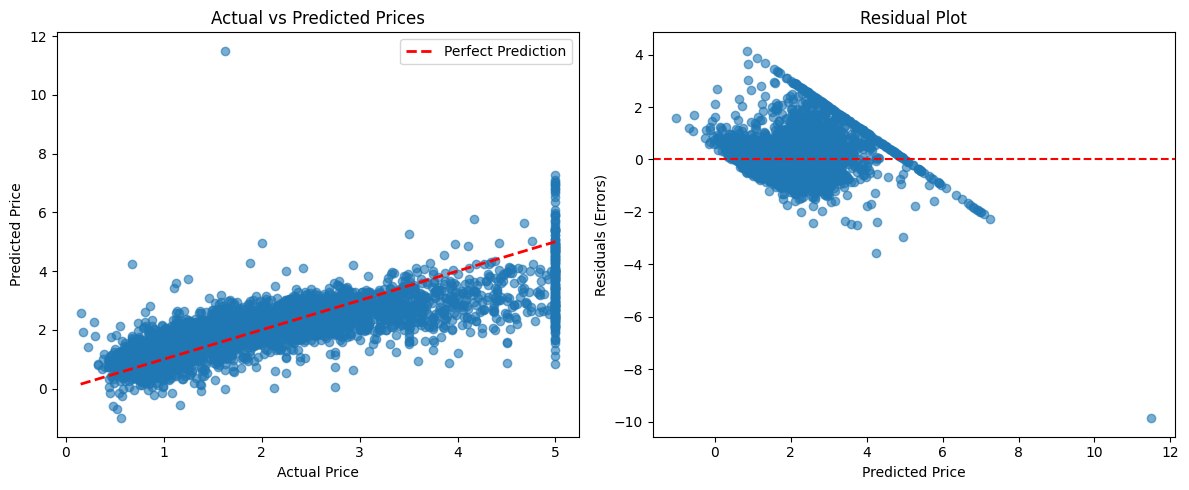

In [ ]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(12, 5))

# Plot 1: Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.legend()

# Plot 2: Residuals (Errors)
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

In [ ]:
# Train data pe bhi accuracy check karo
y_train_pred = model.predict(X_train_scaled)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")

difference = train_r2 - test_r2
print(f"\nDifference: {difference:.4f}")

if difference < 0.05:
    print("✅ Good fit! Model generalize kar raha hai")
elif difference < 0.15:
    print("⚠️ Thoda overfitting, but manageable")
else:
    print("❌ High overfitting! Model ko simplify karo")

Train R²: 0.6126
Test R²:  0.5758

Difference: 0.0368
✅ Good fit! Model generalize kar raha hai


In [ ]:
# Naya ghar aaya - price predict karo!
new_house = pd.DataFrame({
    'MedInc': [5.0],
    'HouseAge': [15.0],
    'AveRooms': [6.0],
    'AveBedrms': [1.2],
    'Population': [1500.0],
    'AveOccup': [3.0],
    'Latitude': [37.5],
    'Longitude': [-122.0]
})

print("🏠 Naya ghar ki details:")
print(new_house)

# Scaling karo (training wale scaler se)
new_house_scaled = scaler.transform(new_house)

# Prediction lagao
predicted_price = model.predict(new_house_scaled)[0]

print(f"\n💰 Predicted Price: ${predicted_price * 100:.2f}k")
print(f"   (₹{predicted_price * 100 * 83:.2f} Lakh - approx)")

🏠 Naya ghar ki details:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0     5.0      15.0       6.0        1.2      1500.0       3.0      37.5   

   Longitude  
0     -122.0  

💰 Predicted Price: $272.23k
   (₹22595.40 Lakh - approx)


In [ ]:
import joblib

# Model save karo
joblib.dump(model, 'house_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model saved!")

# Baad mein load karo
# loaded_model = joblib.load('house_price_model.pkl')
# loaded_scaler = joblib.load('scaler.pkl')

✅ Model saved!
